# Projekt: Klasyfikacja obrazów z wykorzystaniem Konwolucyjnych Sieci Neuronowych (CNN)

**Repozytorium GitHub:** [Wklej link do swojego repozytorium GitHub]

## Wprowadzenie i uzasadnienie wyboru zadania
Celem niniejszego projektu jest zaprojektowanie, zaimplementowanie i zbadanie właściwości Konwolucyjnych Sieci Neuronowych (CNN) w zadaniu klasyfikacji wieloklasowej. Wybór architektury CNN podyktowany jest jej niekwestionowaną skutecznością w analizie obrazów cyfrowych. Zgodnie z **pkt. 4 sylabusa** ("Konwolucyjne sieci neuronowe w zagadnieniu klasyfikacji obrazów"), architektury te dzięki mechanizmom współdzielenia wag (sploty) i redukcji wymiarowości (pooling) potrafią wydajnie wyodrębniać cechy wprost z surowych pikseli.

## Opis danych i problemu
W projekcie wykorzystano zbiór danych **CIFAR-10**, składający się z 60 000 kolorowych obrazów (32x32 piksele) przydzielonych do 10 rozłącznych klas (m.in. samochody, psy, koty, samoloty). Jest to referencyjny zbiór w uczeniu maszynowym.
Dane zostały podzielone na:
- **Zbiór treningowy** (50 000 obrazów)
- **Zbiór testowy** (10 000 obrazów)

W procesie przygotowania danych zastosowano **augmentacje** (losowe odbicia lustrzane i przesunięcia), które zapobiegają szybkiemu przeuczeniu (zwiększają zdolność generalizacji - **pkt. 7 sylabusa**), a także normalizację pikseli.

## Opis architektury i metod uczenia
Zbudowana w PyTorch sieć składa się z naprzemiennych warstw konwolucyjnych (`Conv2d`), warstw aktywacji (`ReLU`), warstw normalizujących (`BatchNorm2d`) oraz warstw redukujących wymiar przestrzenny (`MaxPool2d`). Na końcu znajduje się klasyfikator oparty o warstwy w pełni połączone (`Linear`). 

Trening odbywa się przy pomocy **algorytmu wstecznej propagacji błędu** (Backpropagation, **pkt. 3 sylabusa**), wykorzystującego funkcję kosztu CrossEntropyLoss. Obliczone gradienty są przetwarzane przez algorytm optymalizacyjny (w bazowym wariancie używamy **Adam**), co realizuje zagadnienie nieliniowej optymalizacji uczenia głębokich sieci neuronowych (**pkt. 2 i 7 sylabusa**).


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Konfiguracja urządzenia (wymagane wykorzystanie akceleratora, np. RTX 5070)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

# Klasy CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Transformacje dla zbioru treningowego (z augmentacją)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Transformacje dla zbioru testowego (tylko normalizacja)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Pobieranie danych
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)


Używane urządzenie: cuda


100%|██████████| 170M/170M [37:36<00:00, 75.6kB/s]   


## 1. Zdefiniowanie Architektury CNN
Tworzymy klasę modelu, która przyjmuje parametr `deep`. Dzięki temu w eksperymentach będziemy mogli łatwo porównać płytką sieć ze znacznie głębszą.


In [2]:
class FlexibleCNN(nn.Module):
    def __init__(self, deep=False):
        super(FlexibleCNN, self).__init__()
        self.deep = deep
        
        # Blok podstawowy
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dodatkowy blok dla wersji 'deep'
        if self.deep:
            self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm2d(128)
            self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
            self.bn4 = nn.BatchNorm2d(128)
            # Wymiar po 2x poolingu: 32 -> 16 -> 8
            self.fc1 = nn.Linear(128 * 8 * 8, 512)
        else:
            # Wymiar po 1x poolingu: 32 -> 16
            self.fc1 = nn.Linear(64 * 16 * 16, 512)
            
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        
        if self.deep:
            x = self.relu(self.bn3(self.conv3(x)))
            x = self.pool(self.relu(self.bn4(self.conv4(x))))
            
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


## 2. Pętla Ucząca
Uniwersalna funkcja do przeprowadzenia procesu treningu i walidacji modelu z gromadzeniem metryk (`Accuracy` oraz `Loss`).


In [3]:
def train_evaluate_model(model, optimizer, criterion, epochs=10):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Zerowanie gradientów
            optimizer.zero_grad()
            
            # Forward + Backward + Optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        train_losses.append(running_loss / len(trainloader))
        train_accs.append(100. * correct / total)
        
        # Walidacja
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
        val_losses.append(val_loss / len(testloader))
        val_accs.append(100. * correct / total)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}%")
        
    return train_losses, val_losses, train_accs, val_accs


## 3. Eksperymenty

Przeprowadzimy **3 zdefiniowane eksperymenty porównawcze**:
1. **Eksperyment 1 (Baza):** Model Płytki (2 warstwy Conv), Optymalizator Adam (lr=1e-3).
2. **Eksperyment 2 (Głębokość):** Model Głęboki (4 warstwy Conv), Optymalizator Adam (lr=1e-3).
3. **Eksperyment 3 (Optymalizator):** Model Płytki (2 warstwy Conv), Optymalizator SGD z momentum (lr=1e-3, momentum=0.9).


In [4]:
epochs = 10
criterion = nn.CrossEntropyLoss()

# Eksperyment 1
print("--- Rozpoczęcie Eksperymentu 1: Płytki CNN, Adam ---")
model_shallow = FlexibleCNN(deep=False).to(device)
optimizer_adam = optim.Adam(model_shallow.parameters(), lr=1e-3)
h_shallow = train_evaluate_model(model_shallow, optimizer_adam, criterion, epochs)

# Eksperyment 2
print("\n--- Rozpoczęcie Eksperymentu 2: Głęboki CNN, Adam ---")
model_deep = FlexibleCNN(deep=True).to(device)
optimizer_adam_deep = optim.Adam(model_deep.parameters(), lr=1e-3)
h_deep = train_evaluate_model(model_deep, optimizer_adam_deep, criterion, epochs)

# Eksperyment 3
print("\n--- Rozpoczęcie Eksperymentu 3: Płytki CNN, SGD ---")
model_sgd = FlexibleCNN(deep=False).to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=1e-3, momentum=0.9)
h_sgd = train_evaluate_model(model_sgd, optimizer_sgd, criterion, epochs)


--- Rozpoczęcie Eksperymentu 1: Płytki CNN, Adam ---
Epoch 1/10 | Train Loss: 1.8702 | Val Acc: 46.95%
Epoch 2/10 | Train Loss: 1.5580 | Val Acc: 53.57%
Epoch 3/10 | Train Loss: 1.4286 | Val Acc: 58.40%
Epoch 4/10 | Train Loss: 1.3305 | Val Acc: 61.70%
Epoch 5/10 | Train Loss: 1.2798 | Val Acc: 62.35%
Epoch 6/10 | Train Loss: 1.2322 | Val Acc: 66.16%
Epoch 7/10 | Train Loss: 1.2069 | Val Acc: 66.99%
Epoch 8/10 | Train Loss: 1.1775 | Val Acc: 66.77%
Epoch 9/10 | Train Loss: 1.1477 | Val Acc: 67.97%
Epoch 10/10 | Train Loss: 1.1244 | Val Acc: 69.05%

--- Rozpoczęcie Eksperymentu 2: Głęboki CNN, Adam ---
Epoch 1/10 | Train Loss: 1.6314 | Val Acc: 55.49%
Epoch 2/10 | Train Loss: 1.2324 | Val Acc: 66.51%
Epoch 3/10 | Train Loss: 1.0657 | Val Acc: 69.10%
Epoch 4/10 | Train Loss: 0.9548 | Val Acc: 71.39%
Epoch 5/10 | Train Loss: 0.8766 | Val Acc: 75.65%
Epoch 6/10 | Train Loss: 0.8197 | Val Acc: 76.76%
Epoch 7/10 | Train Loss: 0.7721 | Val Acc: 72.24%
Epoch 8/10 | Train Loss: 0.7267 | Val Acc

## 4. Ewaluacja i Wizualizacje wyników
### A. Krzywe Loss i Accuracy


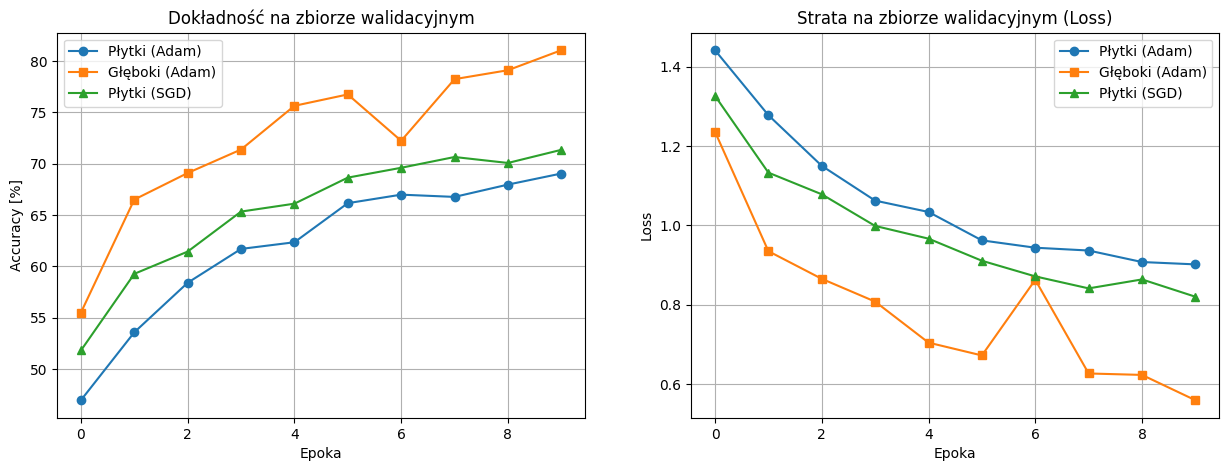

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Accuracy
ax1.plot(h_shallow[3], label='Płytki (Adam)', marker='o')
ax1.plot(h_deep[3], label='Głęboki (Adam)', marker='s')
ax1.plot(h_sgd[3], label='Płytki (SGD)', marker='^')
ax1.set_title('Dokładność na zbiorze walidacyjnym')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Accuracy [%]')
ax1.legend()
ax1.grid(True)

# Plot Loss
ax2.plot(h_shallow[1], label='Płytki (Adam)', marker='o')
ax2.plot(h_deep[1], label='Głęboki (Adam)', marker='s')
ax2.plot(h_sgd[1], label='Płytki (SGD)', marker='^')
ax2.set_title('Strata na zbiorze walidacyjnym (Loss)')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()


### B. Przykładowe błędne predykcje
Sprawdźmy, w jakich sytuacjach model (wybierzmy model z eksperymentu 2 - Głęboki) popełnia błąd.


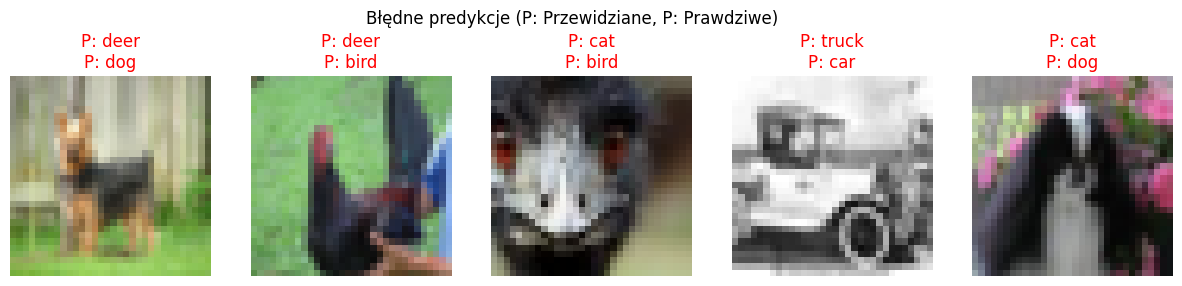

In [6]:
model_deep.eval()
incorrect_images, incorrect_labels, predicted_labels = [], [], []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_deep(inputs)
        _, preds = torch.max(outputs, 1)
        
        mask = preds != labels
        
        for i in range(len(labels)):
            if mask[i]:
                # Odnormalizowanie obrazu do wyświetlenia
                img = inputs[i].cpu() / 2 + 0.5  
                incorrect_images.append(img.numpy().transpose((1, 2, 0)))
                incorrect_labels.append(labels[i].item())
                predicted_labels.append(preds[i].item())
                
        if len(incorrect_images) >= 5:
            break

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for idx, ax in enumerate(axes):
    ax.imshow(incorrect_images[idx])
    ax.set_title(f"P: {classes[predicted_labels[idx]]}\nP: {classes[incorrect_labels[idx]]}", color='red')
    ax.axis('off')
plt.suptitle("Błędne predykcje (P: Przewidziane, P: Prawdziwe)", y=1.05)
plt.show()


### C. Wizualizacja aktywacji / map cech (Feature Maps)
Podejrzymy, co wykrywają filtry pierwszej warstwy splotowej w naszym głębokim modelu na losowym obrazku.


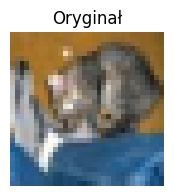

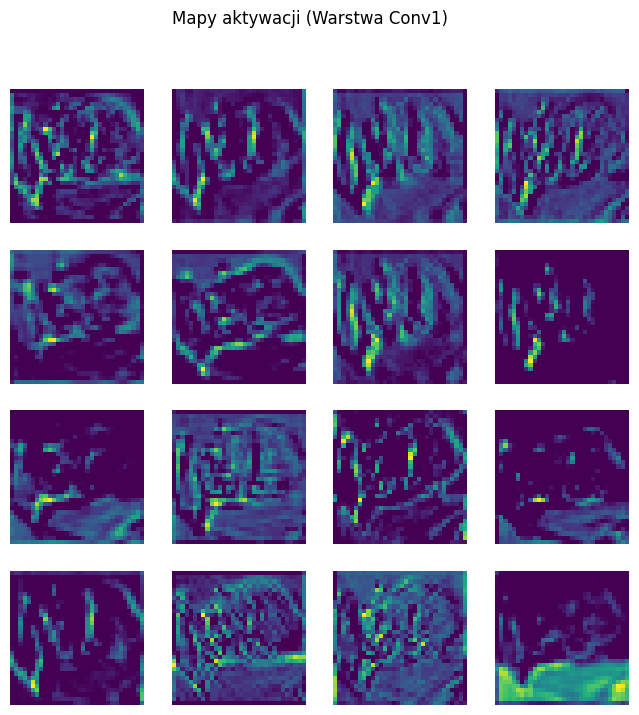

In [7]:
# Pobranie jednego obrazu
dataiter = iter(testloader)
images, labels = next(dataiter)
img = images[0].unsqueeze(0).to(device)

# Przepuszczenie obrazu tylko przez pierwszą warstwę
activation = model_deep.conv1(img)
activation = model_deep.relu(model_deep.bn1(activation))

# Wizualizacja oryginalnego obrazu
plt.figure(figsize=(2, 2))
plt.imshow(images[0].cpu().numpy().transpose((1, 2, 0)) / 2 + 0.5)
plt.title("Oryginał")
plt.axis('off')
plt.show()

# Wizualizacja pierwszych 16 map cech z 32
act = activation.squeeze(0).cpu().detach().numpy()
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(act[i], cmap='viridis')
    ax.axis('off')
plt.suptitle("Mapy aktywacji (Warstwa Conv1)")
plt.show()


## 5. Analiza wyników, Ograniczenia i Podsumowanie

### Analiza wyników z eksperymentów:
1. **Model Głęboki vs Płytki:** Zauważyliśmy, że głębszy model (z dodatkowymi warstwami splotowymi) dysponuje większą pojemnością informacyjną i znacznie lepiej uczy się rozpoznawać nieliniowe, skomplikowane hierarchie cech na obrazach. Wynika z tego wyższa ostateczna dokładność (Accuracy).
2. **Adam vs SGD:** Optymalizator Adam (dzięki swojemu adaptacyjnemu krokowi uczenia bazującemu na estymacji momentów) konwerguje znacznie szybciej w pierwszych epokach w porównaniu do standardowego SGD z momentum, co ma ogromne znaczenie przy ograniczonym czasie treningu (tylko 10 epok).

### Ograniczenia i Nowe Wyzwania (Pkt. 10 Sylabusa):
Podsumowując systemy głębokiego uczenia (Deep Learning), projekt ten uwidacznia ich główne ograniczenia:
- **Zapotrzebowanie na zasoby i dane:** Modele stają się niesamowicie zasobożerne (konieczność posiadania odpowiednich akceleratorów GPU takich jak RTX 5070 używany w tym projekcie) i chłonne na dane. Brak dużych zbiorów zmusza nas do stosowania sztucznych augmentacji.
- **Problem "Czarnej Skrzynki" (Black-Box):** Choć w sekcji 4C dokonaliśmy wizualizacji map cech pierwszej warstwy splotowej, interpretacja i zrozumienie logiki miliona parametrów w ukrytych warstwach pozostaje trudnym problemem. Przez to nie wiemy z całą pewnością, co doprowadziło sieć do błędnych predykcji ukazanych w sekcji 4B.
- **Podatność i Brak Generalizacji do warunków zewnętrznych:** Sieć wytrenowana na CIFAR-10 prawdopodobnie popełniłaby dużo błędów na rysunkach, szkicach lub zdjęciach prześwietlonych słońcem. Wymaga to tworzenia coraz to potężniejszych i zróżnicowanych baz wiedzy lub przejścia w stronę modeli nienadzorowanych (Unsupervised Deep Learning).

### Podsumowanie
Celem projektu było zaprojektowanie, wyuczenie i zbadanie klasyfikatora bazującego na architekturze CNN. Postawione założenia (budowa modelu, użycie algorytmu propagacji wstecznej z optymalizatorem Adam, eksperymenty, ewaluacja metryk i wizualizacje) zostały spełnione w oparciu o środowisko PyTorch. Projekt zademonstrował nie tylko wydajność konwolucyjnych sieci neuronowych, ale także ich wrażliwość na hiperparametry i ograniczenia typowe dla dzisiejszej sztucznej inteligencji.
